### Min Max Scaling

In [32]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
df=pd.read_csv("wine_data.csv",usecols=[0,1,2])
#dfdf = pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['Class label', 'Alcohol', 'Malic acid']
df

,Class label,Alcohol,Malic acid
0,1,13.20,1.78
1,1,13.16,2.36
2,1,14.37,1.95
3,1,13.24,2.59
4,1,14.20,1.76
...,...,...,...
172,3,13.71,5.65
173,3,13.40,3.91
174,3,13.27,4.28
175,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

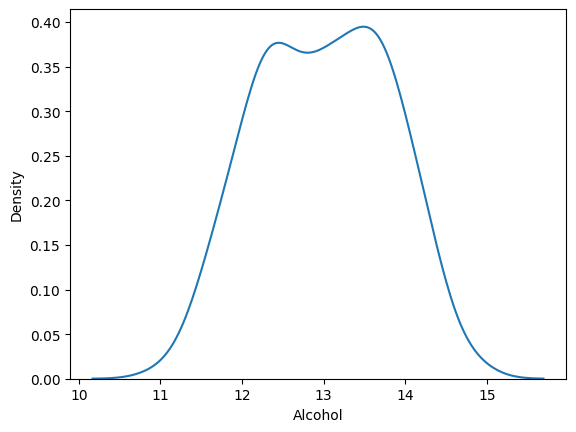

In [34]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

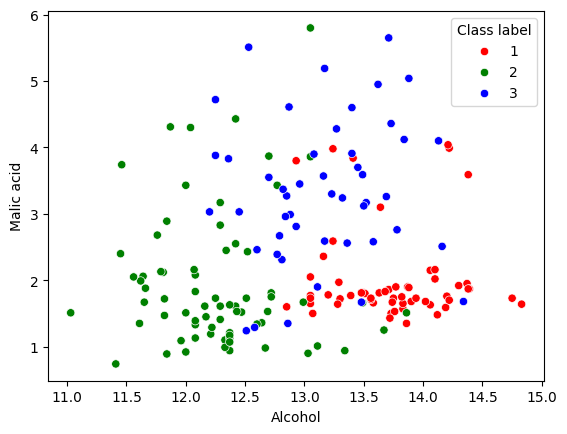

In [35]:
color_dist={1:"red",2:"green",3:"blue"}
sns.scatterplot(data=df,x='Alcohol',y='Malic acid',hue=df['Class label'],palette=color_dist)

In [36]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop(['Class label'],axis=1),df['Class label'],train_size=0.3,random_state=0)
X_train.shape

(53, 2)

In [37]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

#transform data
X_train_Scaled=scaler.transform(X_train)
X_test_Scaled=scaler.transform(X_test)

In [38]:
#Convert the scaled data into data frame
X_train_Scaled=pd.DataFrame(X_train_Scaled,columns=X_train.columns)
X_test_Scaled=pd.DataFrame(X_test_Scaled,columns=X_test.columns)

In [39]:
#Check the info of df
np.round(X_test_Scaled.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.6,0.3
std,0.3,0.2
min,0.1,-0.0
25%,0.4,0.1
50%,0.6,0.2
75%,0.8,0.4
max,1.2,1.0


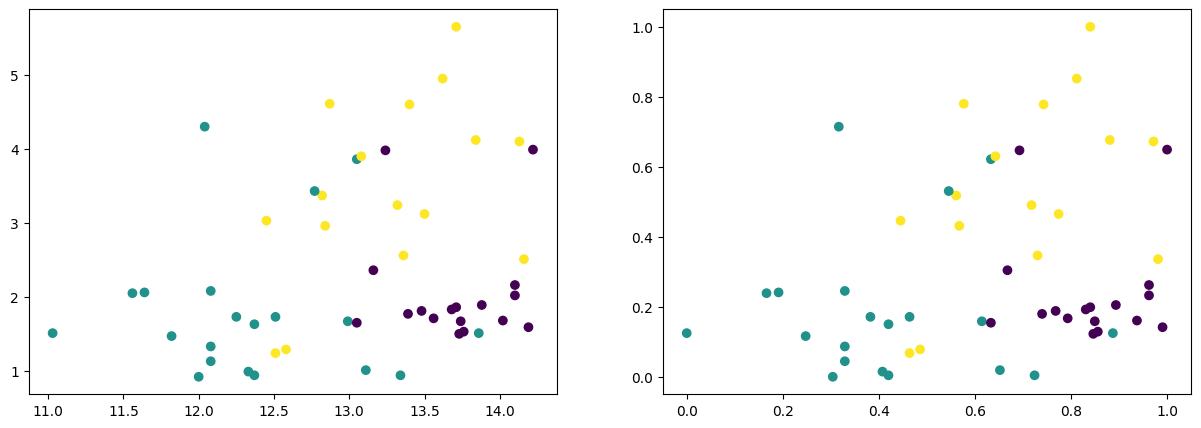

In [42]:
#check the scaling
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(15,5))
ax1.set_title="Before Scaling"
ax1.scatter(X_train['Alcohol'],X_train['Malic acid'],c=y_train)

ax2.set_title="After Scaling"
ax2.scatter(X_train_Scaled['Alcohol'],X_train_Scaled['Malic acid'],c=y_train)
plt.show()

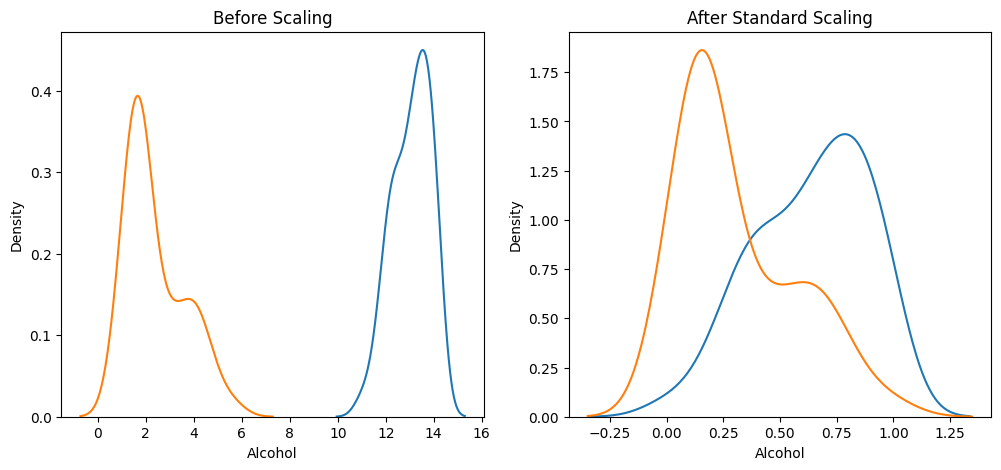

In [44]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_Scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_Scaled['Malic acid'], ax=ax2)
plt.show()
